In [63]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from skopt import BayesSearchCV
from imblearn.pipeline import Pipeline
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler, QuantileTransformer, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.decomposition import PCA, FastICA, KernelPCA
from sklearn.cross_decomposition import PLSRegression, PLSCanonical
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, average_precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

df = pd.read_csv(r"C:\Users\sahay\OneDrive\Desktop\Classification_Problem\Final_Classification_Data.csv")

if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

X = df.drop('Machine_failure', axis=1)
y = df['Machine_failure']


#Split
#1st split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, 
    y, 
    test_size=0.40, 
    random_state=42, 
    stratify=y
)
#2nd split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, 
    y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

EDA OF ALL COLUMNS

Generating Univariate and Bivariate plots for 13 features...



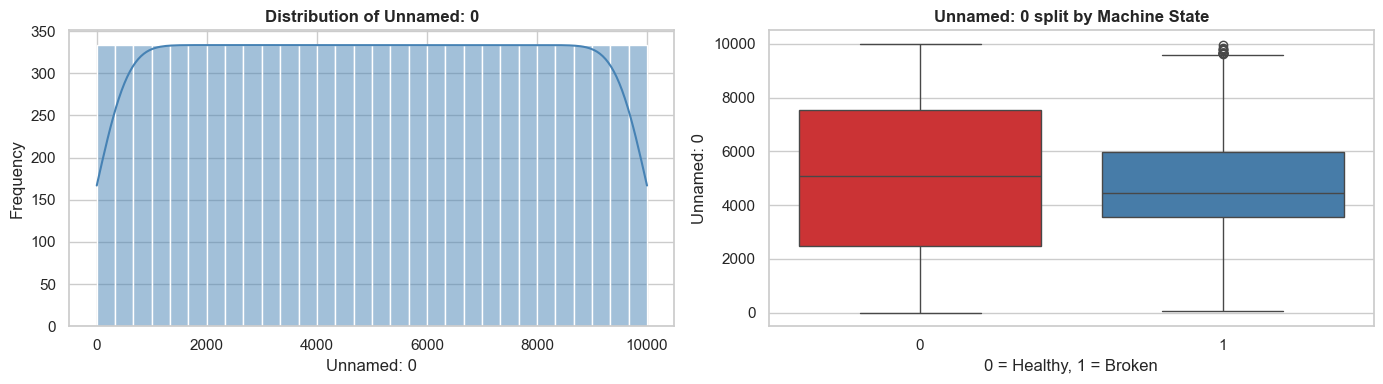

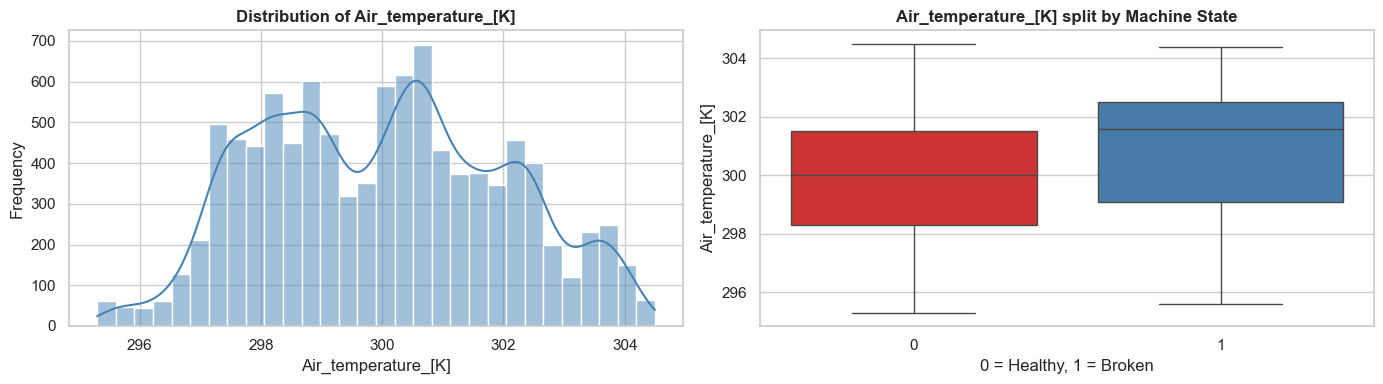

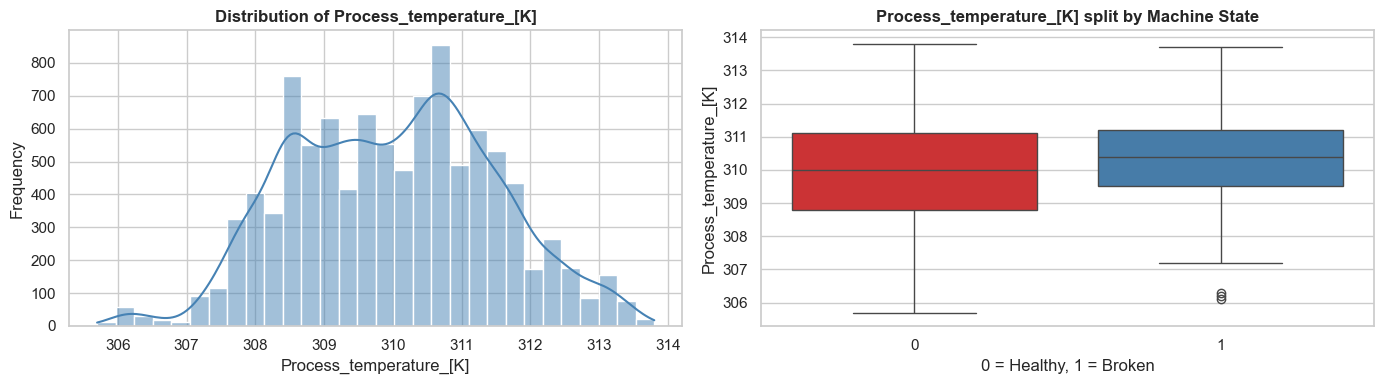

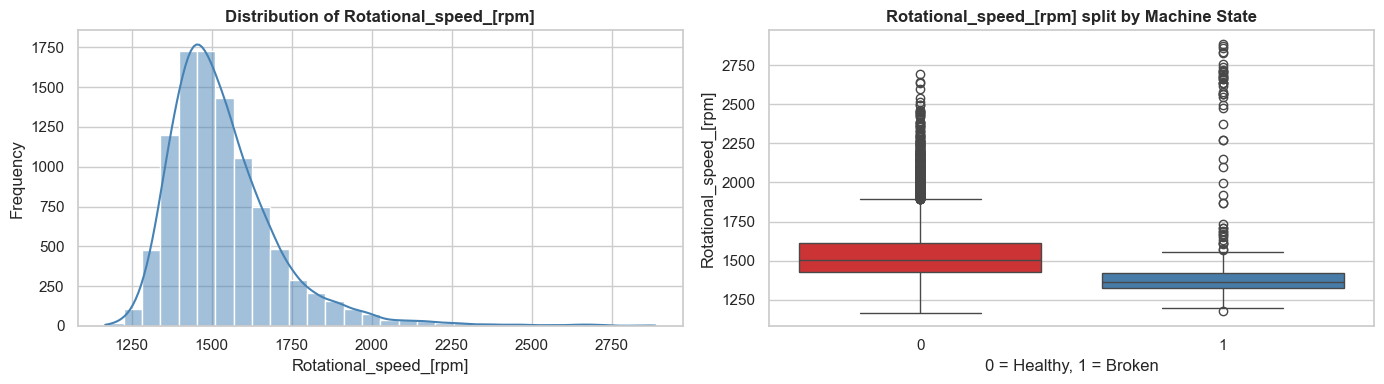

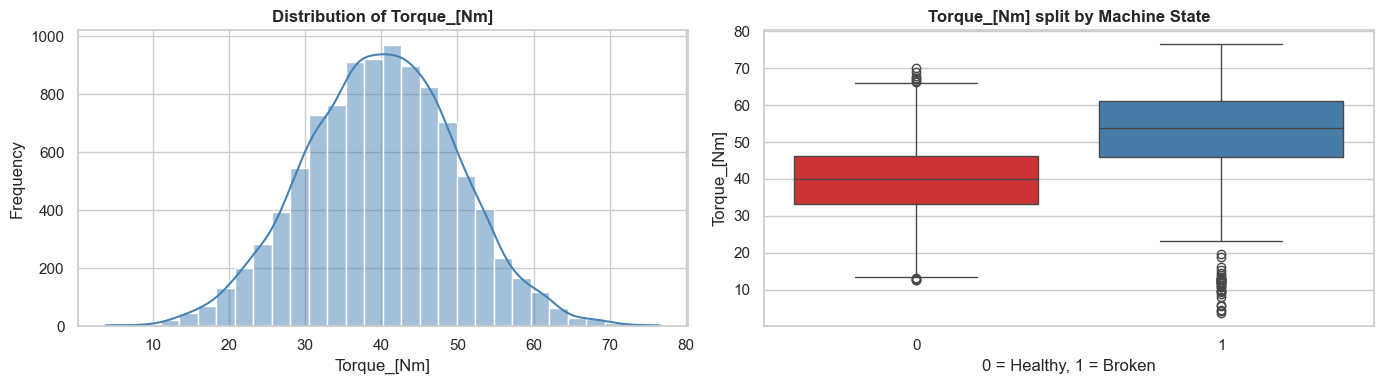

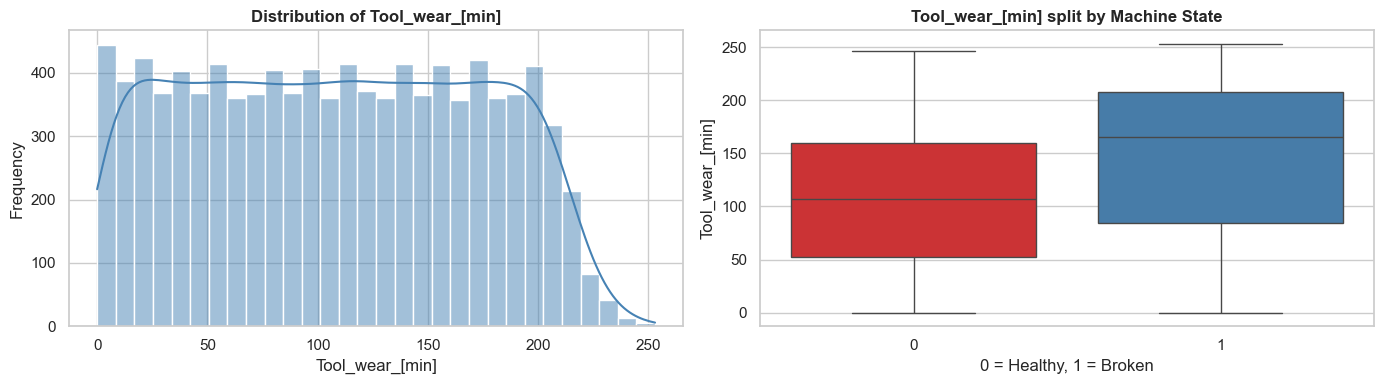

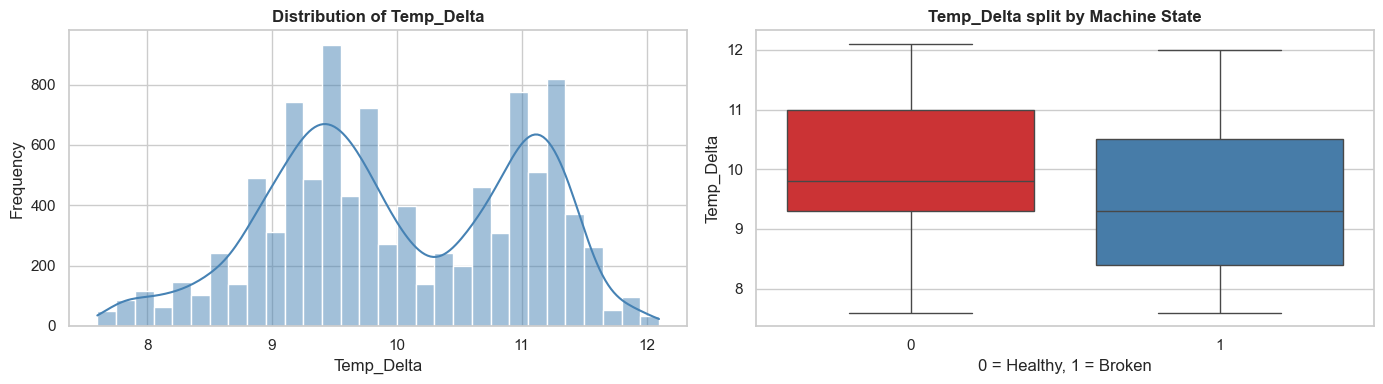

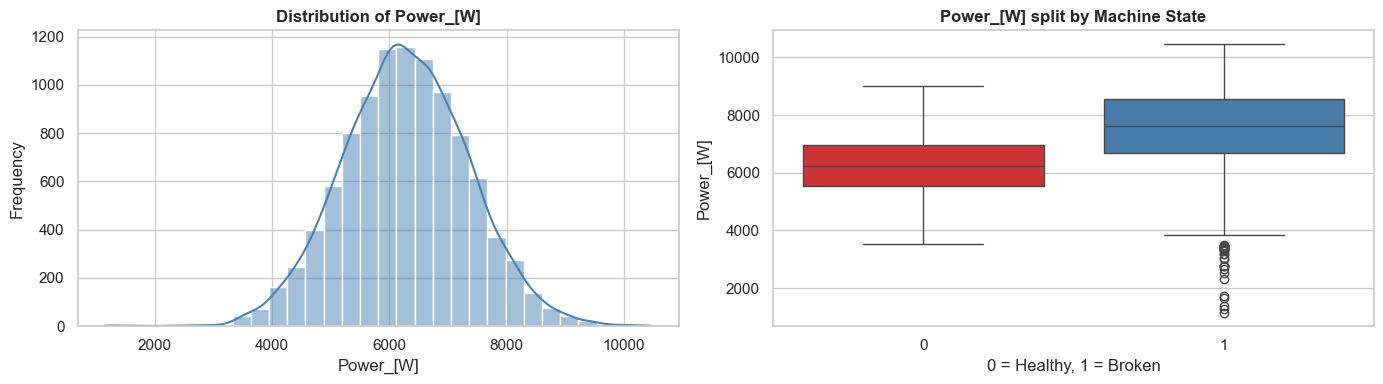

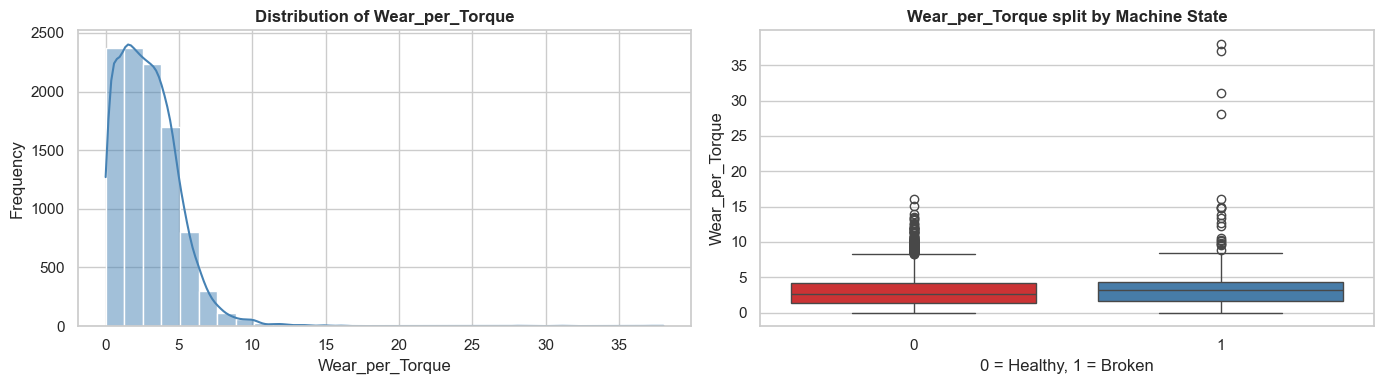

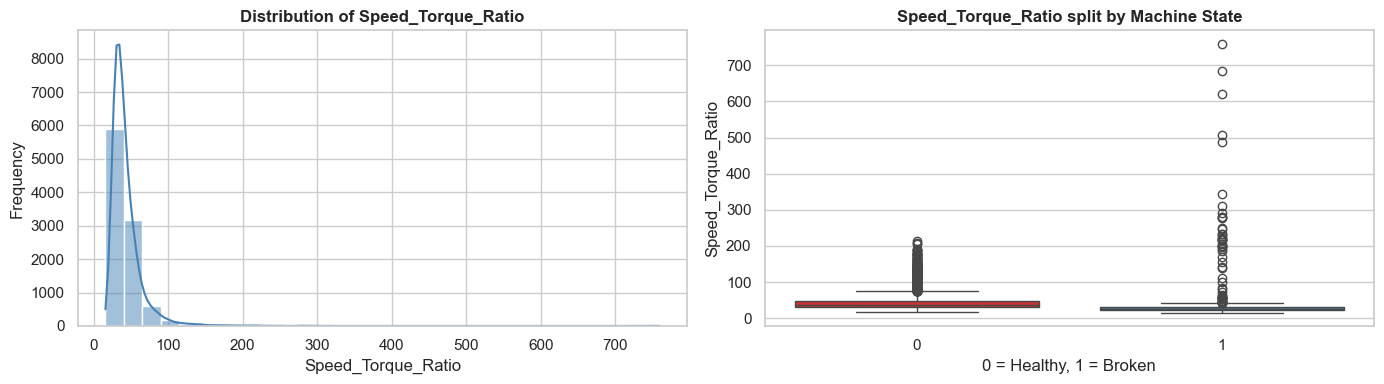

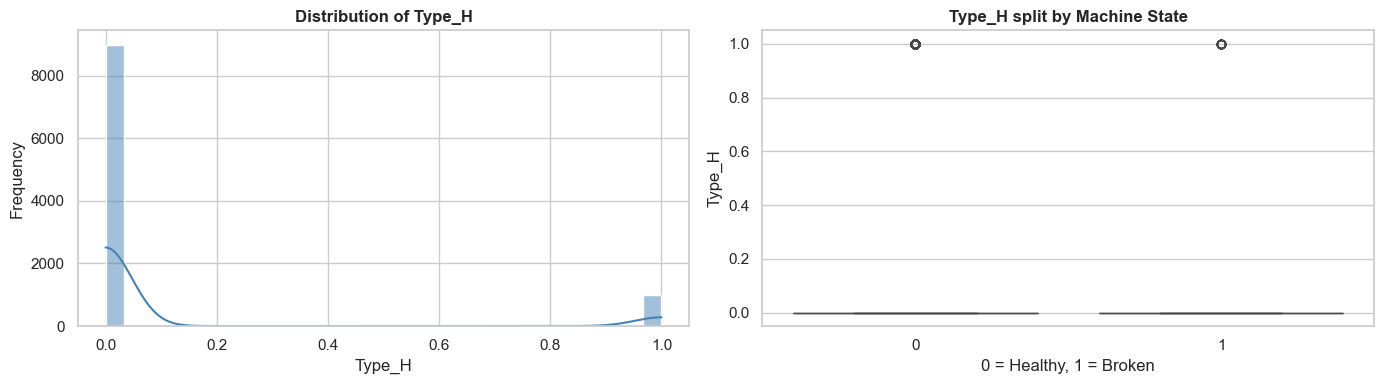

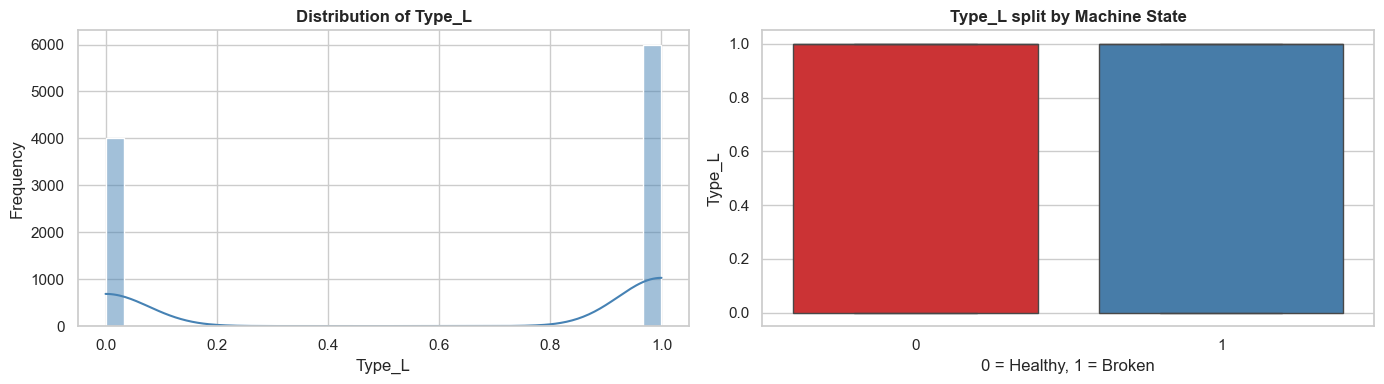

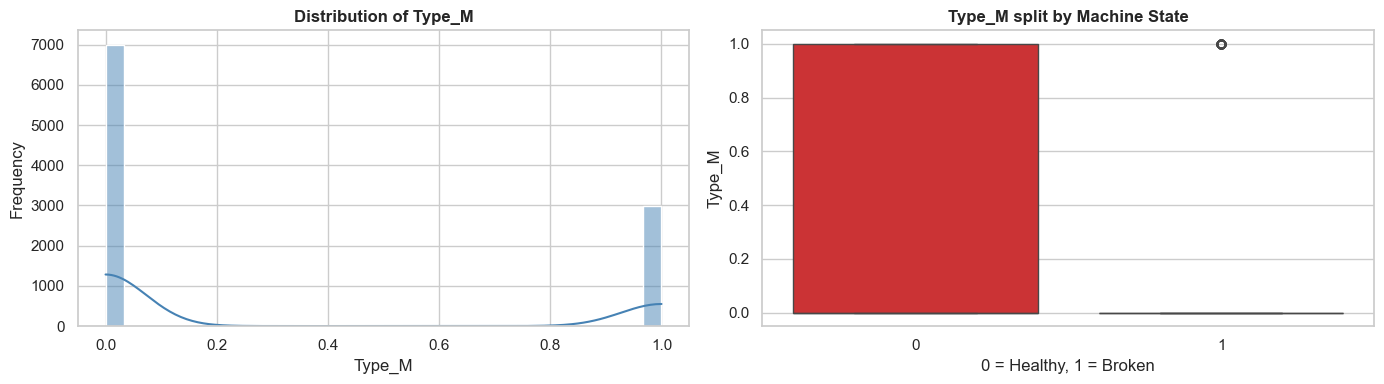

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


target_col = 'Machine_failure'

numerical_features = df.select_dtypes(include=np.number).columns.drop(target_col)

sns.set_theme(style="whitegrid")

print(f"Generating Univariate and Bivariate plots for {len(numerical_features)} features...\n")

for col in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='steelblue', bins=30)
    axes[0].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Frequency')
    
  
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[1], hue=target_col, palette='Set1', legend=False)
    axes[1].set_title(f'{col} split by Machine State', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('0 = Healthy, 1 = Broken')
    axes[1].set_ylabel(col)
    
    plt.tight_layout()
    plt.show()

    

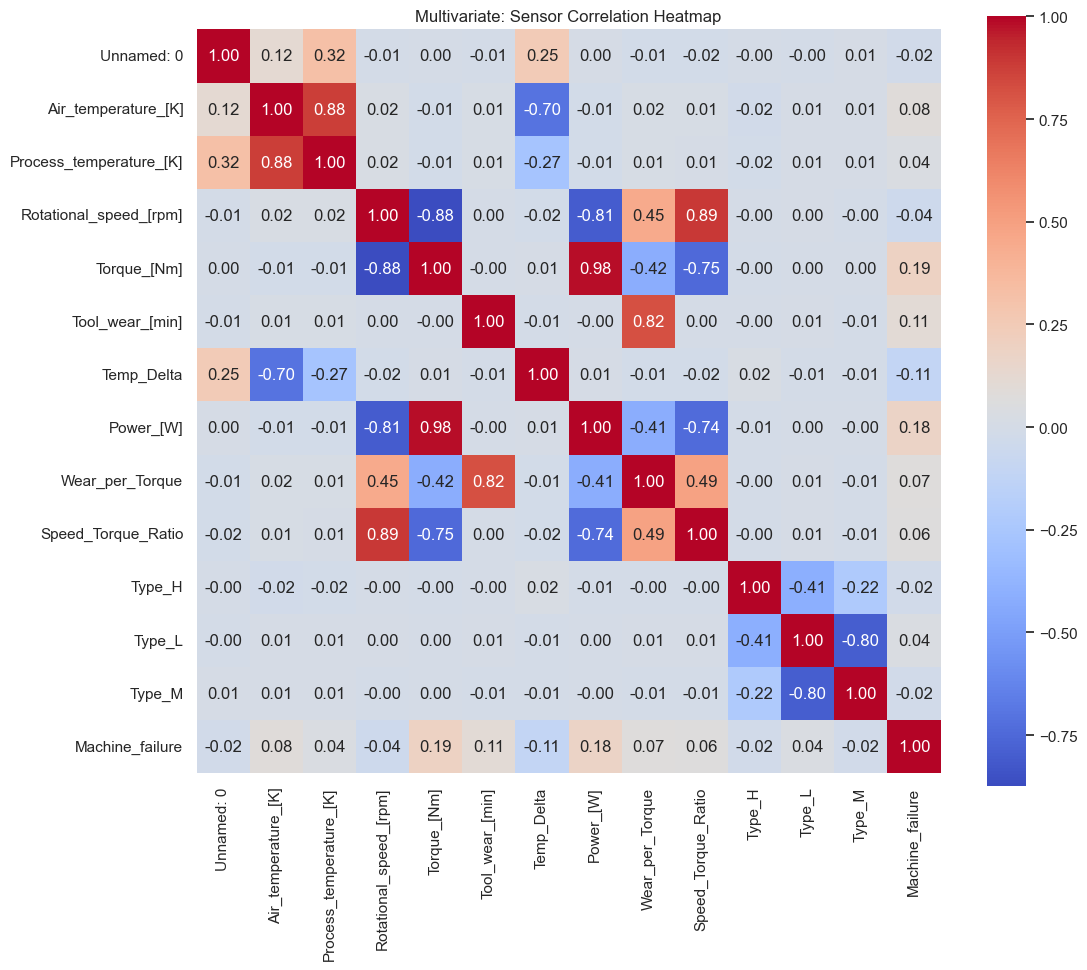

In [ ]:
plt.figure(figsize=(12, 10))

corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)

plt.title('Multivariate: Sensor Correlation Heatmap')
plt.show()

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=29)),
    ('selector', None),
    ('extractor', None),
    ('reducer', None),
    ('clf',LogisticRegression())
])

# Dictionary 
scalers = {
    'standard': StandardScaler(),
    'robust': RobustScaler(),
    'power': PowerTransformer(),
    'quantile': QuantileTransformer(),
    'minmax': MinMaxScaler(),
}
selectors = {
    'kbest': SelectKBest(f_classif, k=6),
    'rfe': RFE(RandomForestClassifier(random_state=29), n_features_to_select=6),
    None: None
}
extractors = {
    'pls_regression': PLSRegression(n_components=3),
    'pls_canonical': PLSCanonical(n_components=3),
    'lda': LDA(n_components=1),
    None: None
}
reducers = {
    'pca': PCA(n_components=0.95),
    'kpca': KernelPCA(n_components=5, kernel='rbf'),
    'ica': FastICA(n_components=5, random_state=29),
    None: None
}
models = {
    'logreg': LogisticRegression(max_iter=1000),
    'rf': RandomForestClassifier(random_state=29),
    'svc': SVC(random_state=29),
    'mlp': MLPClassifier(max_iter=300, random_state=29),
    'extratrees': ExtraTreesClassifier(random_state=29),
    'xgb': XGBClassifier(eval_metric='logloss', random_state=29),
    'catboost': CatBoostClassifier(verbose=0, random_state=29),
}


Finding best scaler (with SMOTE)

In [14]:
pipe.set_params(
    selector=None, 
    extractor=None, 
    reducer=None, 
    clf=models['rf']
)
print("The best scaler-")
scaler_results=[]
for name, scalers in scalers.items():
    pipe.set_params(scaler=scaler)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    f1 = f1_score(y_val, y_pred, pos_label=1)
    scaler_results.append({'Scaler': name, 'F1': f1})
    print(f"{name}: F1-Score = {f1:.4f}")

    scaler_df = pd.DataFrame(scaler_results).sort_values(by='F1', ascending=False)
best_scaler_name = scaler_df.iloc[0]['Scaler']
print(f"\n🏆 Winner: {best_scaler_name}")


The best scaler-


AttributeError: 'StandardScaler' object has no attribute 'items'

In [49]:
pipe.set_params(
    selector=None, 
    extractor=None, 
    reducer=None, 
    clf=models['rf']
)
print("The best scaler-")
scaler_results=[]
for scaler_name, scaler in scalers.items():
    pipe_copy = clone(pipe)
    pipe_copy.set_params(scaler=scaler)
    pipe_copy.set_params(scaler=scaler)
    pipe_copy.fit(X_train, y_train)
    y_pred = pipe_copy.predict(X_val)
    f1 = f1_score(y_val, y_pred, pos_label=1)
    scaler_results.append({'Scaler': scaler_name, 'F1': f1})
    print(f"{scaler_name}: F1-Score = {f1:.4f}")

scaler_df = pd.DataFrame(scaler_results).sort_values(by='F1', ascending=False)
best_scaler_name = scaler_df.iloc[0]['Scaler']

The best scaler-
standard: F1-Score = 0.6541
robust: F1-Score = 0.7034
power: F1-Score = 0.6624
quantile: F1-Score = 0.6584
minmax: F1-Score = 0.6316


SO I REMOVE SMOTE BECAUSE IT IS CAUSING SKEWNESS

In [50]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', None),
    ('extractor', None),
    ('reducer', None),
    ('clf',LogisticRegression())
])

# Dictionary 
scalers = {
    'standard': StandardScaler(),
    'robust': RobustScaler(),
    'power': PowerTransformer(),
    'quantile': QuantileTransformer(),
    'minmax': MinMaxScaler(),
}
selectors = {
    'kbest': SelectKBest(f_classif, k=6),
    'rfe': RFE(RandomForestClassifier(random_state=29), n_features_to_select=6),
    None: None
}
extractors = {
    'pls_regression': PLSRegression(n_components=3),
    'pls_canonical': PLSCanonical(n_components=3),
    'lda': LDA(n_components=1),
    None: None
}
reducers = {
    'pca': PCA(n_components=0.95),
    'kpca': KernelPCA(n_components=5, kernel='rbf'),
    'ica': FastICA(n_components=5, random_state=29),
    None: None
}
models = {
    'logreg': LogisticRegression(max_iter=1000),
    'rf': RandomForestClassifier(random_state=29),
    'svc': SVC(random_state=29),
    'mlp': MLPClassifier(max_iter=300, random_state=29),
    'extratrees': ExtraTreesClassifier(random_state=29),
    'xgb': XGBClassifier(eval_metric='logloss', random_state=29),
    'catboost': CatBoostClassifier(verbose=0, random_state=29)
}


In [51]:
pipe.set_params(
    selector=None, 
    extractor=None, 
    reducer=None, 
    clf=models['rf']
)
print("The best scaler-")
scaler_results=[]
for scaler_name, scaler in scalers.items():
    pipe_copy = clone(pipe)
    pipe_copy.set_params(scaler=scaler)
    pipe_copy.set_params(scaler=scaler)
    pipe_copy.fit(X_train, y_train)
    y_pred = pipe_copy.predict(X_val)
    f1 = f1_score(y_val, y_pred, pos_label=1)
    scaler_results.append({'Scaler': scaler_name, 'F1': f1})
    print(f"{scaler_name}: F1-Score = {f1:.4f}")

scaler_df = pd.DataFrame(scaler_results).sort_values(by='F1', ascending=False)
best_scaler_name = scaler_df.iloc[0]['Scaler']

The best scaler-
standard: F1-Score = 0.8333
robust: F1-Score = 0.8333
power: F1-Score = 0.8235
quantile: F1-Score = 0.8333
minmax: F1-Score = 0.8333


In [52]:
pipe.set_params(
    scaler=scalers['robust'],
    extractor=None, 
    reducer=None, 
    clf=models['rf']
)
print("The best feature selector -")
selector_results = []
for name, selector in selectors.items():
    pipe_copy = clone(pipe)
    pipe_copy.set_params(selector=selector)

    pipe_copy.fit(X_train, y_train)
    y_pred = pipe_copy.predict(X_val)

    f1 = f1_score(y_val, y_pred, pos_label=1)
    selector_results.append({'Selector': name, 'F1' : f1})
    print(f"{name}: F1-Score = {f1:.4f}")

selector_df = pd.DataFrame(selector_results).sort_values(by='F1', ascending=False)
best_selector_name = selector_df.iloc[0]['Selector']

The best feature selector -
kbest: F1-Score = 0.7652
rfe: F1-Score = 0.8235
None: F1-Score = 0.8333


In [53]:
pipe.set_params(
    scaler=scalers['robust'],
    selector = None, 
    reducer=None, 
    clf=models['rf']
)
print("The best feature extractor -")
extractor_results = []
for name, extractor in extractors.items():
    pipe_copy = clone(pipe)
    pipe_copy.set_params(extractor=extractor)

    pipe_copy.fit(X_train, y_train)
    y_pred = pipe_copy.predict(X_val)

    f1 = f1_score(y_val, y_pred, pos_label=1)
    extractor_results.append({'Extractor': name, 'F1' : f1})
    print(f"{name}: F1-Score = {f1:.4f}")

extractor_df = pd.DataFrame(extractor_results).sort_values(by='F1', ascending=False)
best_extractor_name = extractor_df.iloc[0]['Extractor']

The best feature extractor -


ValueError: Found array with dim 3, while dim <= 2 is required by RandomForestClassifier.

In [54]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', None),
    ('extractor', None),
    ('reducer', None),
    ('clf',LogisticRegression())
])

# Dictionary 
scalers = {
    'standard': StandardScaler(),
    'robust': RobustScaler(),
    'power': PowerTransformer(),
    'quantile': QuantileTransformer(),
    'minmax': MinMaxScaler(),
}
selectors = {
    'kbest': SelectKBest(f_classif, k=6),
    'rfe': RFE(RandomForestClassifier(random_state=29), n_features_to_select=6),
    None: None
}
extractors = {
    'lda': LDA(n_components=1),
    None: None
}
reducers = {
    'pca': PCA(n_components=0.95),
    'kpca': KernelPCA(n_components=5, kernel='rbf'),
    'ica': FastICA(n_components=5, random_state=29),
    None: None
}
models = {
    'logreg': LogisticRegression(max_iter=1000),
    'rf': RandomForestClassifier(random_state=29),
    'svc': SVC(random_state=29),
    'mlp': MLPClassifier(max_iter=300, random_state=29),
    'extratrees': ExtraTreesClassifier(random_state=29),
    'xgb': XGBClassifier(eval_metric='logloss', random_state=29),
    'catboost': CatBoostClassifier(verbose=0, random_state=29)
}


In [55]:
pipe.set_params(
    scaler=scalers['robust'],
    selector = None, 
    reducer=None, 
    clf=models['rf']
)
print("The best feature extractor -")
extractor_results = []
for name, extractor in extractors.items():
    pipe_copy = clone(pipe)
    pipe_copy.set_params(extractor=extractor)

    pipe_copy.fit(X_train, y_train)
    y_pred = pipe_copy.predict(X_val)

    f1 = f1_score(y_val, y_pred, pos_label=1)
    extractor_results.append({'Extractor': name, 'F1' : f1})
    print(f"{name}: F1-Score = {f1:.4f}")

extractor_df = pd.DataFrame(extractor_results).sort_values(by='F1', ascending=False)
best_extractor_name = extractor_df.iloc[0]['Extractor']

The best feature extractor -
lda: F1-Score = 0.2000
None: F1-Score = 0.8333


In [57]:
pipe.set_params(
    scaler=scalers['robust'],
    selector = None, 
    extractor=None, 
    clf=models['rf']
)
print("The best feature reducer -")
reducer_results = []
for name, reducer in reducers.items():
    pipe_copy = clone(pipe)
    pipe_copy.set_params(reducer=reducer if name != 'none' else None)

    pipe_copy.fit(X_train, y_train)
    y_pred = pipe_copy.predict(X_val)

    f1 = f1_score(y_val, y_pred, pos_label=1)
    reducer_results.append({'Reducer': name, 'F1' : f1})
    print(f"{name}: F1-Score = {f1:.4f}")

reducer_df = pd.DataFrame(reducer_results).sort_values(by='F1', ascending=False)
best_reducer_name = reducer_df.iloc[0]['Reducer']

The best feature reducer -
pca: F1-Score = 0.5000
kpca: F1-Score = 0.3297
ica: F1-Score = 0.5882
None: F1-Score = 0.8333


NOW RUNNING THE FINALIZED PIPELINE ON ALL THE IMPORTED CLASSIFIERS

In [61]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', None),
    ('extractor', None),
    ('reducer', None),
    ('clf',LogisticRegression())
])

# Dictionary 
scalers = {
    'standard': StandardScaler(),
    'robust': RobustScaler(),
    'power': PowerTransformer(),
    'quantile': QuantileTransformer(),
    'minmax': MinMaxScaler(),
}
selectors = {
    'kbest': SelectKBest(f_classif, k=6),
    'rfe': RFE(RandomForestClassifier(random_state=29), n_features_to_select=6),
    None: None
}
extractors = {
    'lda': LDA(n_components=1),
    None: None
}
reducers = {
    'pca': PCA(n_components=0.95),
    'kpca': KernelPCA(n_components=5, kernel='rbf'),
    'ica': FastICA(n_components=5, random_state=29),
    None: None
}
models = {
    'logreg': LogisticRegression(max_iter=1000),
    'rf': RandomForestClassifier(random_state=29),
    'svc': SVC(random_state=29),
    'mlp': MLPClassifier(max_iter=300, random_state=29),
    'extratrees': ExtraTreesClassifier(random_state=29),
    'xgb': XGBClassifier(eval_metric='logloss', random_state=29),
    'catboost': CatBoostClassifier(verbose=0, random_state=29),
    'ridge': RidgeClassifier(class_weight='balanced', random_state=29),
    'nb': GaussianNB(),
    'knn': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    'dt': DecisionTreeClassifier(class_weight='balanced', random_state=29),
    'adaboost': AdaBoostClassifier(random_state=29),
    'hist_gb': HistGradientBoostingClassifier(class_weight='balanced', random_state=29)
}


Including Stratified k fold validation on the data

In [ ]:
pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('clf', LogisticRegression())
])

print("THE BEST MODEL IS -")
model_results = []

models = {
    'logreg': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=29),
    'ridge': RidgeClassifier(class_weight='balanced', random_state=29),
    'svc': SVC(class_weight='balanced', random_state=29),
    
    
    'nb': GaussianNB(),
    'knn': KNeighborsClassifier(n_neighbors=5, weights='distance'),
    
    
    'mlp': MLPClassifier(max_iter=500, random_state=29),
    
    
    'dt': DecisionTreeClassifier(class_weight='balanced', random_state=29),
    
    
    'rf': RandomForestClassifier(class_weight='balanced', random_state=29),
    'extratrees': ExtraTreesClassifier(class_weight='balanced', random_state=29),
    
    
    'adaboost': AdaBoostClassifier(random_state=29),
    'hist_gb': HistGradientBoostingClassifier(class_weight='balanced', random_state=29),
    'xgb': XGBClassifier(eval_metric='logloss', scale_pos_weight=30, random_state=29),
    'catboost': CatBoostClassifier(verbose=0, auto_class_weights='Balanced', random_state=29)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=29)

print("The best model for our data is = ")
model_results = []

for name, model in models.items():
    pipe_copy = clone(pipe)
    
    pipe_copy.set_params(clf=model)
    cv_scores = cross_val_score(
        pipe_copy, 
        X_train, 
        y_train, 
        cv=skf, 
        scoring='f1', 
        n_jobs=-1 
    )
    
    mean_f1 = cv_scores.mean()
    std_f1 = cv_scores.std()
    
    model_results.append({
        'Model': name, 
        'Mean F1': mean_f1, 
        'Std Dev': std_f1
    })
    
    print(f"Finished {name: <12} -> Mean F1: {mean_f1:.4f} (± {std_f1:.4f})")
final_df = pd.DataFrame(model_results).sort_values(by='Mean F1', ascending=False).reset_index(drop=True)
print("\nFINAL MODEL LEADERBOARD")
print(final_df.to_string())

THE BEST MODEL IS -
The best model for our data is = 
Finished logreg       -> Mean F1: 0.2826 (± 0.0207)
Finished ridge        -> Mean F1: 0.2957 (± 0.0246)
Finished svc          -> Mean F1: 0.4143 (± 0.0206)
Finished nb           -> Mean F1: 0.2861 (± 0.0638)
Finished knn          -> Mean F1: 0.5040 (± 0.0449)
Finished mlp          -> Mean F1: 0.7063 (± 0.0599)
Finished dt           -> Mean F1: 0.6993 (± 0.0753)
Finished rf           -> Mean F1: 0.7625 (± 0.0578)
Finished extratrees   -> Mean F1: 0.6356 (± 0.0676)
Finished adaboost     -> Mean F1: 0.5106 (± 0.0723)
Finished hist_gb      -> Mean F1: 0.7403 (± 0.0535)
Finished xgb          -> Mean F1: 0.8085 (± 0.0602)
Finished catboost     -> Mean F1: 0.7757 (± 0.0398)

FINAL MODEL LEADERBOARD
         Model   Mean F1   Std Dev
0          xgb  0.808541  0.060158
1     catboost  0.775738  0.039803
2           rf  0.762452  0.057844
3      hist_gb  0.740275  0.053518
4          mlp  0.706301  0.059890
5           dt  0.699312  0.075258


HYPERPARAMETER TUNING

In [ ]:
import time
from sklearn.model_selection import GridSearchCV

final_pipe = Pipeline([
    ('scaler', RobustScaler()), 
    ('clf', XGBClassifier(eval_metric='logloss', scale_pos_weight=30, random_state=29))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'clf__n_estimators': [100, 300],         
    'clf__max_depth': [3, 5, 7],               
    'clf__learning_rate': [0.01, 0.1]       
}

grid_search = GridSearchCV(
    estimator=final_pipe, 
    param_grid=param_grid, 
    scoring='f1', 
    cv=skf,      
    n_jobs=-1    
)

print("RUNNING GRID SEARCH")
start_time = time.time()

grid_search.fit(X_train, y_train)

elapsed_minutes = (time.time() - start_time) / 60
print(f"Grid Search finished in {elapsed_minutes:.2f} minutes.")
print(f"Best F1-Score: {grid_search.best_score_:.4f}")
print("Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f" - {param.replace('clf__', '')}: {value}")

RUNNING GRID SEARCH
Grid Search finished in 0.02 minutes.
Best F1-Score: 0.8014
Best Parameters:
 - learning_rate: 0.1
 - max_depth: 7
 - n_estimators: 300


In [ ]:
import time
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'clf__n_estimators': randint(100, 400),
    'clf__max_depth': randint(3, 8),
    'clf__learning_rate': uniform(0.01, 0.15)
}

# 2. Setup Randomized Search
random_search = RandomizedSearchCV(
    estimator=final_pipe, 
    param_distributions=param_dist, 
    n_iter=60,
    scoring='f1', 
    cv=skf, 
    n_jobs=-1, 
    random_state=42
)

print("\nRUNNING RANDOMIZED SEARCH ")
start_time = time.time()

random_search.fit(X_train, y_train)

elapsed_minutes = (time.time() - start_time) / 60
print(f"Randomized Search finished in {elapsed_minutes:.2f} minutes.")
print(f"Best F1-Score: {random_search.best_score_:.4f}")
print("Best Parameters:")
for param, value in random_search.best_params_.items():
    print(f" - {param.replace('clf__', '')}: {value}")


RUNNING RANDOMIZED SEARCH 
Randomized Search finished in 0.10 minutes.
Best F1-Score: 0.8034
Best Parameters:
 - learning_rate: 0.11670129291229749
 - max_depth: 5
 - n_estimators: 388


In [69]:
import time
from skopt import BayesSearchCV
from skopt.space import Real, Integer

param_bayes = {
    'clf__n_estimators': Integer(100, 400),
    'clf__max_depth': Integer(3, 8),
    'clf__learning_rate': Real(0.01, 0.15, prior='log-uniform')
}

bayes_search = BayesSearchCV(
    estimator=final_pipe, 
    search_spaces=param_bayes, 
    n_iter=60,
    scoring='f1', 
    cv=skf, 
    n_jobs=-1, 
    random_state=42
)

print("\nRUNNING BAYESIAN SEARCH")
start_time = time.time()

bayes_search.fit(X_train, y_train)

elapsed_minutes = (time.time() - start_time) / 60
print(f"Bayesian Search finished in {elapsed_minutes:.2f} minutes.")
print(f"Best F1-Score: {bayes_search.best_score_:.4f}")
print("Best Parameters:")
for param, value in bayes_search.best_params_.items():
    print(f" - {param.replace('clf__', '')}: {value}")


RUNNING BAYESIAN SEARCH
Bayesian Search finished in 0.94 minutes.
Best F1-Score: 0.8170
Best Parameters:
 - learning_rate: 0.11372963888953223
 - max_depth: 6
 - n_estimators: 305


FINAL TESTING OF MODEL ON TEST DATA

Training the final optimized model on combined Train+Val data...
Predicting on the untouched Test set...

FINAL UNSEEN F1-SCORE: 0.7746

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.74      0.81      0.77        68

    accuracy                           0.98      2000
   macro avg       0.87      0.90      0.88      2000
weighted avg       0.98      0.98      0.98      2000



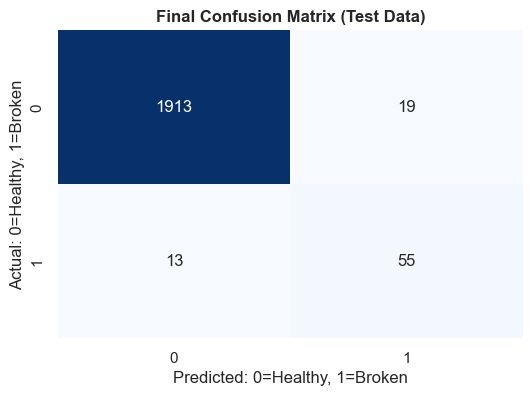

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
import pandas as pd

final_optimized_pipe = Pipeline([
    ('scaler', RobustScaler()), 
    ('clf', XGBClassifier(
        n_estimators=305,
        max_depth=6,
        learning_rate=0.11372963888953223,
        eval_metric='logloss', 
        scale_pos_weight=30, 
        random_state=29
    ))
])

X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

print("Training the final optimized model on combined Train+Val data...")
final_optimized_pipe.fit(X_train_final, y_train_final)

print("Predicting on the untouched Test set...\n")
y_test_pred = final_optimized_pipe.predict(X_test)

final_f1 = f1_score(y_test, y_test_pred, pos_label=1)
print(f"FINAL UNSEEN F1-SCORE: {final_f1:.4f}\n")

print("--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_test_pred))

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Final Confusion Matrix (Test Data)', fontweight='bold')
plt.xlabel('Predicted: 0=Healthy, 1=Broken')
plt.ylabel('Actual: 0=Healthy, 1=Broken')
plt.show()